#### Learning MCP, LangChain and LangGraph - Simple

In [1]:
import os

from dotenv import load_dotenv
from typing import TypedDict, Annotated, Sequence
from langchain_classic.schema import BaseMessage, SystemMessage, AIMessage, HumanMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from langchain_mcp_adapters.client import MultiServerMCPClient

In [2]:
load_dotenv(override=True)

openai_api_key = os.getenv("OPENAI_API_KEY")

if not openai_api_key:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

model = ChatOpenAI(
    model="gpt-5.2",
    openai_api_key=openai_api_key,
    temperature=0.0)

In [3]:
# Combine MCP tools with local tools
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Adds two integers and returns the result."""
    return a+b

@tool
def subtract(a: int, b: int) -> int:
    """Subtracts the second integer from the first and returns the result."""
    return a - b

@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two integers and returns the result."""
    return a * b


In [4]:
server_params = {
    "task-manager": {
        "transport": "sse",
        "url": "http://localhost:8100/sse"
    },
    "remote-file-system": {
        "transport": "sse",
        "url": "http://localhost:8200/sse"
    }
}

client = MultiServerMCPClient(server_params)
mcp_tools = await client.get_tools()

In [5]:
print(f"Successfully loaded {len(mcp_tools)} MCP tools:")

for tool in mcp_tools:
    print(f"  - {tool.name}")

Successfully loaded 17 MCP tools:
  - create_task
  - complete_task
  - list_tasks
  - read_file
  - read_text_file
  - read_media_file
  - read_multiple_files
  - write_file
  - edit_file
  - create_directory
  - list_directory
  - list_directory_with_sizes
  - directory_tree
  - move_file
  - search_files
  - get_file_info
  - list_allowed_directories


In [6]:
# Combine all tools
all_tools = mcp_tools + [add, subtract, multiply]

print(f"\nTotal tools available: {len(all_tools)}")

for tool in all_tools:
    print(f"  - {tool.name}")

# Bind all tools to the model
model = model.bind_tools(all_tools)


Total tools available: 20
  - create_task
  - complete_task
  - list_tasks
  - read_file
  - read_text_file
  - read_media_file
  - read_multiple_files
  - write_file
  - edit_file
  - create_directory
  - list_directory
  - list_directory_with_sizes
  - directory_tree
  - move_file
  - search_files
  - get_file_info
  - list_allowed_directories
  - add
  - subtract
  - multiply


In [7]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [8]:
import asyncio
from langchain_core.tools import BaseTool
from langchain_core.messages import ToolMessage

async def execute_tools_async(state: AgentState, tools_list: list[BaseTool]) -> AgentState:
    """
    Execute MCP tools with proper async session management.
    Keeps the client context alive throughout the entire execution.
    """
    last_message = state["messages"][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return state
    
    # Create a mapping of tool names to tools for efficient lookup
    tool_map = {tool.name: tool for tool in tools_list}
    
    # Execute all tool calls concurrently
    tool_results = []
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call.get("args", {})
        
        if tool_name not in tool_map:
            result = f"Error: Tool '{tool_name}' not found"
        else:
            try:
                # Invoke tool asynchronously, keeping MCP session alive
                tool = tool_map[tool_name]
                if hasattr(tool, 'ainvoke'):
                    result = await tool.ainvoke(tool_args)
                else:
                    # Fallback for non-async tools
                    result = tool.invoke(tool_args)
            except Exception as e:
                result = f"Error executing {tool_name}: {str(e)}"
        
        tool_results.append(
            ToolMessage(
                content=str(result),
                name=tool_name,
                tool_call_id=tool_call["id"]
            )
        )
    
    return {"messages": tool_results}

In [9]:
async def model_call(state: AgentState) -> AgentState:
    """Call the model with system message."""
    system = SystemMessage(
        content="""You're a helpful assistant. 
               Use tools when needed and share results clearly.
            """
    )

    conversation = [system] + state["messages"]
    reply = model.invoke(conversation)

    return {"messages": [reply]}


def should_continue(state: AgentState) -> str:
    """Decide whether to continue with tool execution or end."""
    last = state["messages"][-1]
    
    if isinstance(last, AIMessage) and last.tool_calls:
        return "continue"

    return "end"

In [10]:
from langchain_core.runnables import RunnableLambda

graph = StateGraph(AgentState)

# Create custom tool executor node that preserves MCP client context
async def execute_tools_node(state: AgentState) -> AgentState:
    """Execute tools while keeping MCP client alive."""
    return await execute_tools_async(state, all_tools)

graph.add_node("think", RunnableLambda(model_call))
graph.add_node("all_tools", RunnableLambda(execute_tools_node))

graph.add_edge(START, "think")
graph.add_conditional_edges("think", should_continue, {
    "continue": "all_tools",
    "end": END,
})
graph.add_edge("all_tools", "think")

app = graph.compile()

In [11]:
query_content = """
                 can you generate a simple task with task manager stating that we're learning MCP, 
                 LangChain and LangGraph with Claude, and should be completed automatically. 
                 Retrieve all tasks and calculate three added with hundred. 
                 Both the results from tasks and calculation to be written them into the file named c:\\data\\collection-results.txt 
                 in the file system.
"""
query = AgentState(messages=[
    HumanMessage(content=query_content)
])

In [12]:
output = await app.ainvoke(query)

print(output)

{'messages': [HumanMessage(content="\n                 can you generate a simple task with task manager stating that we're learning MCP, \n                 LangChain and LangGraph with Claude, and should be completed automatically. \n                 Retrieve all tasks and calculate three added with hundred. \n                 Both the results from tasks and calculation to be written them into the file named c:\\data\\collection-results.txt \n                 in the file system.\n", additional_kwargs={}, response_metadata={}, id='bffd6b3d-dfa5-4391-9022-35b048bfe5b3'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 1494, 'total_tokens': 1541, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-202

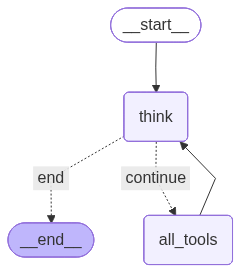

In [13]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass